In [7]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import os

regions = ["H1", "H2", "L1", "L2", "L3"]
seq_regions = ["SEQ_H1", "SEQ_H2", "SEQ_L1", "SEQ_L2", "SEQ_L3"]
cf_regions = ["CF_H1", "CF_H2", "CF_L1", "CF_L2", "CF_L3"]
len_regions = ["LEN_H1", "LEN_H2", "LEN_L1", "LEN_L2", "LEN_L3"]
meta_cols = ["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species"]


ab_ag_scalop = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset = seq_regions)
    .dropna(subset = cf_regions)
    .drop_duplicates(subset = seq_regions) 
)

antigen_counts = ab_ag_scalop["antigen_name"].value_counts() # Tabelle aus antigen_names und ihren Häufigkeiten in der Spalte antigen_name
ab_ag_scalop = ab_ag_scalop[ab_ag_scalop["antigen_name"].isin(antigen_counts[antigen_counts >= 7].index)]# Behält nur Zeilen, deren antigen_name mindestens 5-mal vorkommt

if not os.path.exists("data/chi2_visuals"):
    os.makedirs("data/chi2_visuals")

In [3]:
# Struktur von regions_dict:
# {
# "CDR_H1" : {H1_len_group_1 : H1_contingency_1, ..., H1_len_group_n : H1_contingency_n},
# "CDR_H2" : {H2_len_group_1 : H2_contingency_1, ..., H2_len_group_n : H2_contingency_n},
# "CDR_L1" : {L1_len_group_1 : L1_contingency_1, ..., L1_len_group_n : L1_contingency_n},
# "CDR_L2" : {L2_len_group_1 : L2_contingency_1, ..., L2_len_group_n : L2_contingency_n},
# "CDR_L3" : {L3_len_group_1 : L3_contingency_1, ..., L3_len_group_n : L3_contingency_n}
# }

regions_dict = {}

for region, seq_region, cf_region, len_region in zip(regions, seq_regions, cf_regions, len_regions):

    # DataFrame für jede Region, der alle Sequenzen nach Längengruppe und Cluster sortiert

    df = ab_ag_scalop[meta_cols + [seq_region, cf_region]].copy() # Erstellt eue Kopie von df für jede Region, damit nicht jede Region den originalen df überschreibt
    df[len_region] = df[seq_region].str.len() # Neue Spalte für die Sequenzlänge
    df = df.sort_values(by=[len_region, cf_region]) # Sortiert nach Länge und Cluster (nur optisch für das Debugging nötig)

    len_groups = df[len_region].unique().tolist() # Liste an Längengruppen, die in einer Region vorkommen
    len_groups_dict = {} # Dictionary initialisieren für die DataFrames aller gültigen Längen-Gruppen

    for len_group in len_groups:
        df_len = df[df[len_region] == len_group] # Zeilen aus dem großen DataFrame filtern, die zur gleichen Längengruppe gehören
        len_groups_dict[len_group] = df_len # gefilterten DataFrame in das Dictionary aufnehmen

    regions_dict[region] = len_groups_dict # Dictionary für DataFrames derselben Region in ein äußeres Dictionary anlegen

In [4]:
# Normalisiere Antigen-Counts innerhalb der Cluster (Zeilen)
# Achtung: normalisierte Kontingenztabelle nicht geeignet für Chi2, sondern nur für grafische Darstellung der Antigen-Verteilung in den Clustern

def normalize_contingency(contingency):
    # contingency ist aufgebaut: Cluster (Zeilen): axis=0, Antigen (Spalten): axis=1
    row_sums = contingency.sum(axis=1)
    # axis=1 heißt "gehe entlang der spalten" --> Summe der ZEILEN werden berechnet
    normalized = contingency.div(row_sums.where(row_sums != 0, other=1), axis=0) # Mittelwert: Teile Felder durch die Summe der Zeile, wenn sie nicht 0 ist
    normalized.loc[row_sums == 0, :] = 0 # Bleibe bei allen Feldern bei 0 aus Zeilen deren Summe bereits 0 war
    return normalized

In [5]:
def permutation_test_and_bootstrap(contingency, n_permutations, bootstrap_iterations, seed=None):
    np.random.seed(seed)
    # Setzt Startpunkt der Generation von Zufallszahlen fest, damit Ergebnisse bei Wiederholung vergleichbar sind

    # Beobachtete Teststatistik
    chi2_obs, _, dof, _ = chi2_contingency(contingency)
    # chi2_contingency führt einen klassischen Chi2-Unabhängigkeitstest basierend auf der beobachteten Kontingenztabelle durch, d.h:
    # - berechnet beobachtete Teststatistik Chi2 = (Oij - Eij)^2/Eij
    # - vergleicht beobachteten Chi2-Wert mit theoretischer Chi2-Verteilung und gibt p-Wert (entfällt, weil Annahme der theoretischen Chi2-Verteilung ungültig)
    # - gibt dof der Kontingenztabelle bei festen Randwerten aus (hier nicht benötigt)
    # - gibt theoretische Kontingenztabelle mit den Erwartungswerten Eij = ((Summe der Zeile i) * (Summe der Spalte j))/Gesamtsumme aus (hier nicht benötigt)

    # Einträge der Kontingenztabelle als Liste
    data = contingency.stack().reset_index().values.tolist()
    # .stack(): Erstellt aus der Kontingenztabelle eine pd.Series (Index: (Cluster i, Antigen j), Wert: Oij) DATENTYP
    # .reset_index(): Erstellt aus pd.Series mit zweiwertigem Index und einem Wert eine Tabelle mit 3 Spalten (Cluster i, Antigen j, Oij) DATENTYP
    # .values(): Erstellt einen np.ndarray aus der Tabelle
    # .tolist(): Erstellt aus der np.ndarray eine Liste an Listen

    rows = contingency.index.tolist() # Liste der Reihennamen der Kontingenztabelle (Cluster), jedes Cluster kommt 1x vor
    cols = contingency.columns.tolist() # Liste der Spaltennamen der Kontingentabelle (Antigene), jedes Antigen kommt 1x vor
    
    values = []
    groups = []
    for row, col, count in data: # Für jedes Feld in der Kontingenztabelle (Feld wird definiert durch row (Cluster), col (Antigen) und count)
        for _ in range(count):
            values.append(col) # values: Liste an Antigenen, jedes Antigen kommt count mal vor durch die Schleife
            groups.append(row) # groups: Liste an Clustern, jedes Cluster kommt count mal vor durch die Schleife
    pairs = list(zip(groups, values))

    # Empirischen p-Wert  berechnen
    greater_equal_count = 0 # Zähler initialisieren, wie oft ein permutierter Chi2-Wert mind. so groß ist wie der beobachtete Chi2-Wert
    for _ in range(n_permutations):
        shuffled = np.random.permutation(values) # Erzeuge eine zufällige Permutation der beobachteten Antigen-Häufigkeiten
        shuffled_table = pd.crosstab(groups, shuffled) # Erstelle eine Kontingenztabelle aus den permutierten Antigen-Häufigkeiten und den beobachteten Cluster-Häufigkeiten
        shuffled_table = shuffled_table.reindex(index=rows, columns=cols, fill_value=0)
        # Falls durch Permutation manche Antigene gar nicht mehr vorkommen, entfällt die Spalte nicht in der Kontingenztabelle, sondern die Felder bekommen count = 0
        chi2_perm, _, _, _ = chi2_contingency(shuffled_table) # wie oben, nur Chi2-Wert ist relevant
        if chi2_perm >= chi2_obs:
            greater_equal_count += 1 # Anzahl an Permutationen, die einen Chi2-Wert ergeben, der den beobachteten Chi2-Wert übertrifft
    p_value = greater_equal_count / n_permutations # empirischer p-Wert: Wahrscheinlichkeit, dass eine Permutation einen Chi2-Wert ergibt, der den beobachteten Chi2-Wert übertrifft

    # Bootstrapping für Fehlerbalken
    # Achtung: Die Fehlerbalken beschreiben NICHT, die Unsicherheit bezogen darauf, wie die Balken aussehen würden, wenn der beobachtete Datensatz einer "Grundgesamtheit" entsprechen würde
    # sondern die Unsicherheit bezogen darauf, dass man evtl. aus derselben beobachteten Stichprobe z.B. vermehrt Antigen A in Cluster 1 ziehen könnte, obwohl in der beobachteten Stichprobe auch viel Antigen B in Cluster 1 liegt!
    bootstrap_results = [] # Liste initialisieren für die 
    for _ in range(bootstrap_iterations): # Ziehe n mal 
        resampled_pairs = [pairs[i] for i in np.random.choice(len(pairs), size=len(pairs), replace=True)] # ziehe das i-te Element aus der Liste pairs, die die Tupel (Cluster, Antigen) aus der beobachteten Verteilung enthält, mit zurücklegen
        resampled_clusters = [pair[0] for pair in resampled_pairs]  # Cluster
        resampled_antigens = [pair[1] for pair in resampled_pairs]  # Antigen
        resampled_contingency = pd.crosstab(resampled_clusters, resampled_antigens).reindex(index=rows, columns=cols, fill_value=0)

        resampled_contingency_norm = normalize_contingency(resampled_contingency)
        # Relative Häufigkeiten in den Zeilen (Cluster) --> Randsumme der Zeilen (Cluster) ist immer 1
        # gespeichert als pd.DataFrame

        bootstrap_results.append(resampled_contingency_norm.values)
        # .values macht numpy.ndarray aus dem pd.DataFrame
        # .append: fügt neues Element in die Liste der normierten Kontingenztabelle hinzu. Jedes Element entspricht einer normierten Kontingenztabelle als np.ndarray)
        # bootstrap_iterations: axis=0,  cluster: axis=1, antigen: axis=2
    
    bootstrap_array = np.array(bootstrap_results)
    # wandelt die Liste an np-2Darrays in np.3Darray um --> Jedes Feld der Kontingenztabelle enthält nicht mehr eine Einzelmessung, sondern eine Verteilung aus den Zufallsziehungen aus der beobachteten Verteilung
    error_matrix = bootstrap_array.std(axis=0)
    # berechnet für jedes Feld der normierten Kontingenztabelle aus Verteilungen statt Einzelmessungen die Standardabweichung

    error_df = pd.DataFrame(error_matrix, index=rows, columns=cols)
    # Gleiche Form wie die beobachtete Kontingenztabelle, aber enthält approximierte Standardabweichung statt beobachtete Einzelmessung

    return chi2_obs, p_value, dof, error_df


H1 - Länge 7:Chi² = 59.39, p = 0.3470, dof = 54


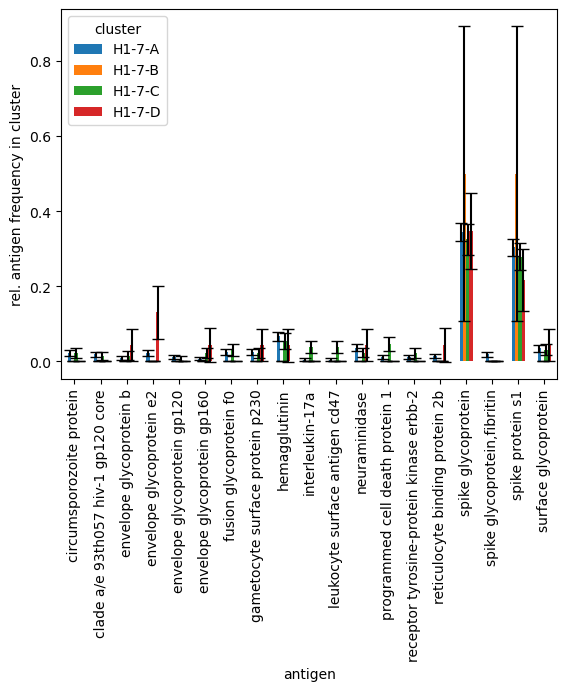

H1 - Länge 8:Chi² = 6.00, p = 0.9620, dof = 6


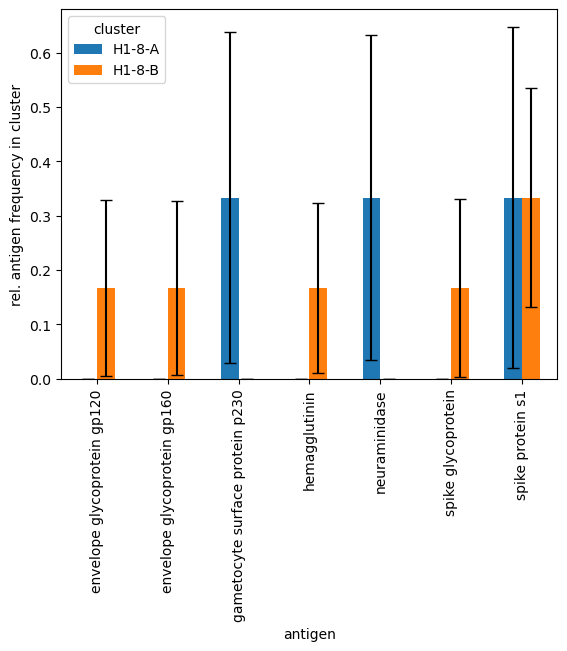

H1 - Länge 9:Chi² = 13.31, p = 0.0460, dof = 7


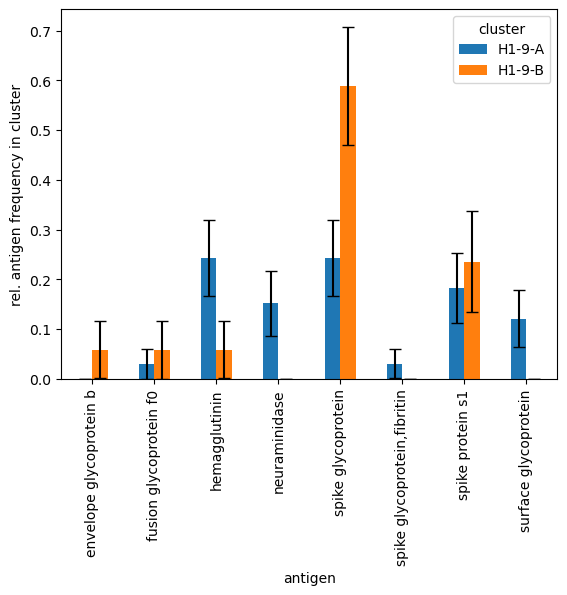

H2 - Länge 5:Chi² = 0.00, p = 1.0000, dof = 0


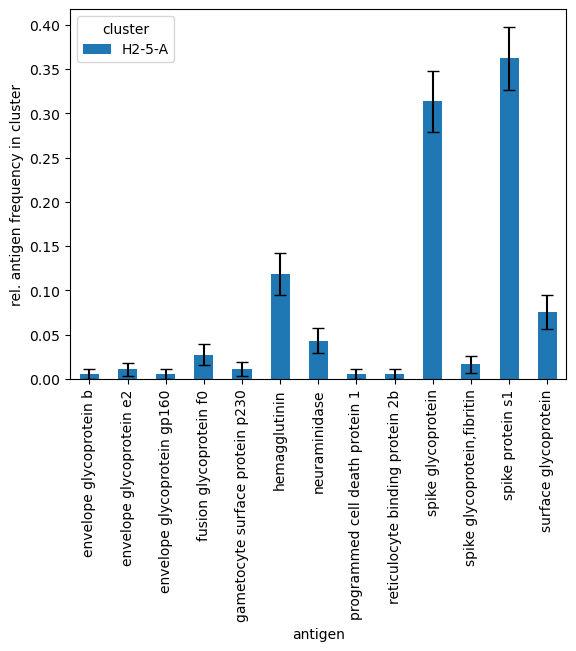

H2 - Länge 6:Chi² = 171.27, p < 0.0010, dof = 72


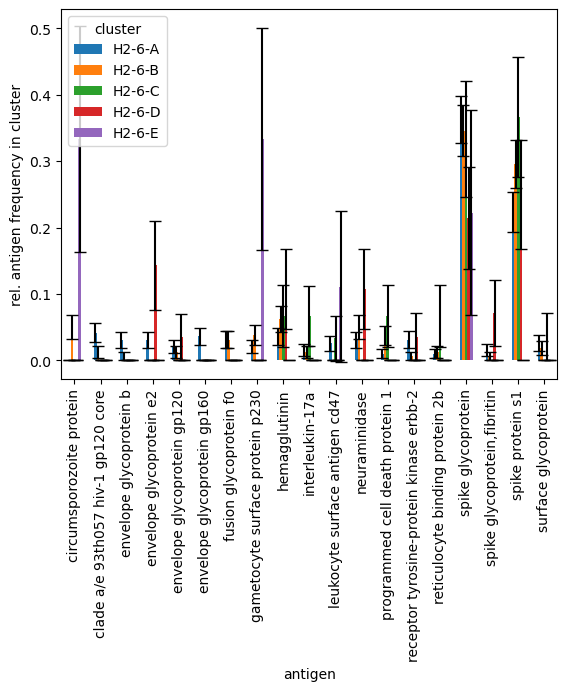

H2 - Länge 8:Chi² = 0.00, p = 1.0000, dof = 0


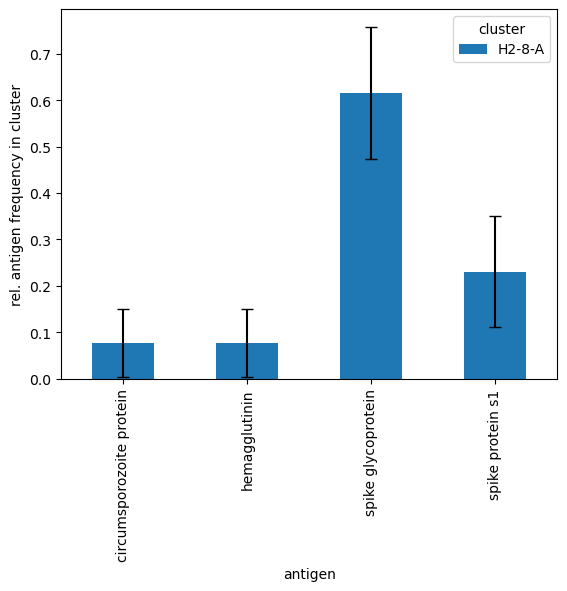

L1 - Länge 10:Chi² = 0.00, p = 1.0000, dof = 0


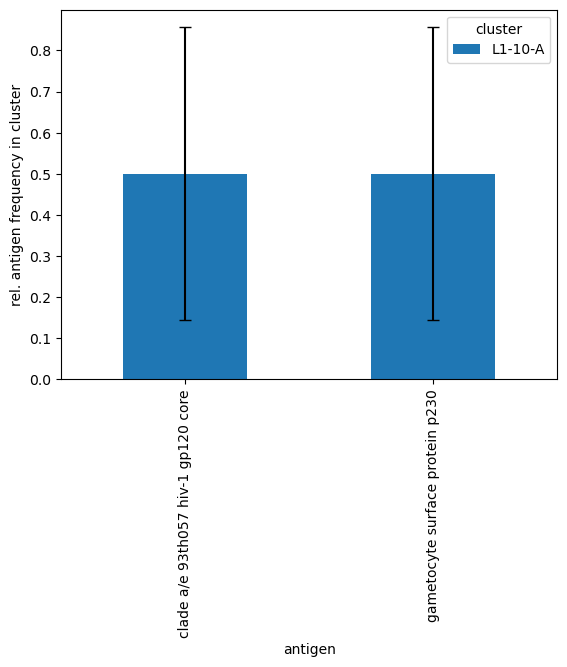

L1 - Länge 11:Chi² = 40.27, p = 0.0040, dof = 18


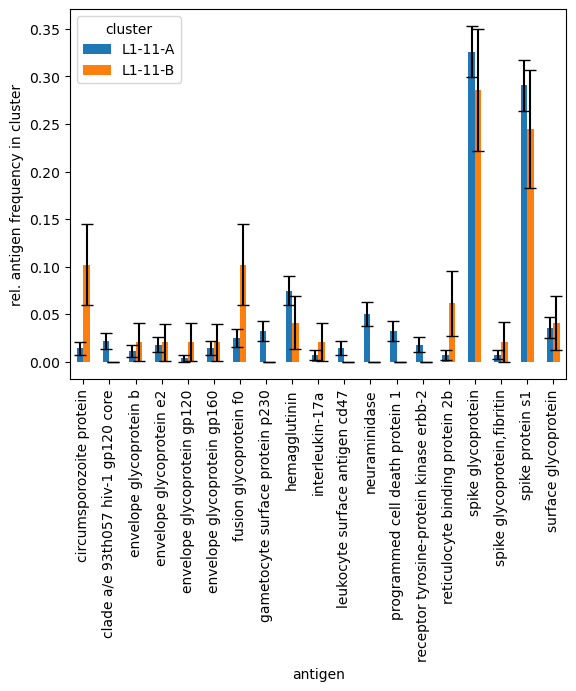

L1 - Länge 12:Chi² = 17.95, p = 0.1450, dof = 13


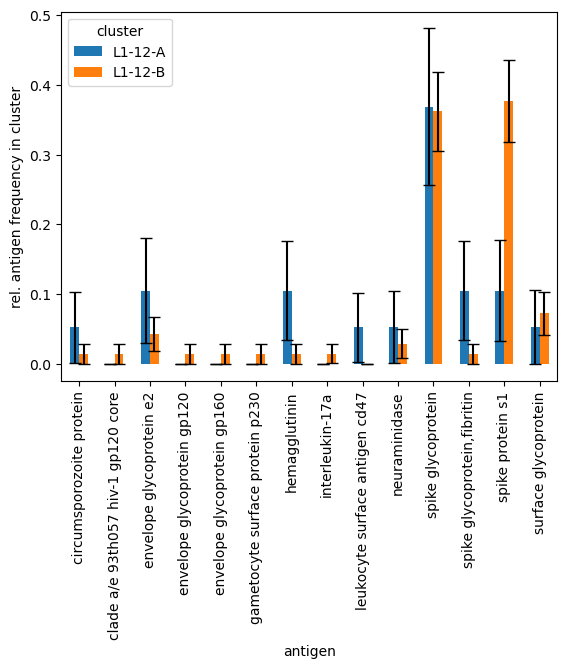

L1 - Länge 13:Chi² = 11.27, p = 0.2000, dof = 9


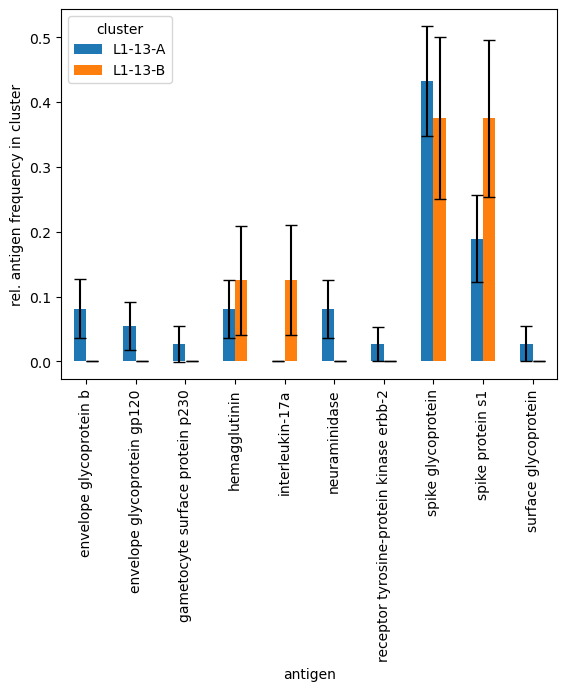

L1 - Länge 14:Chi² = 16.71, p = 0.4530, dof = 24


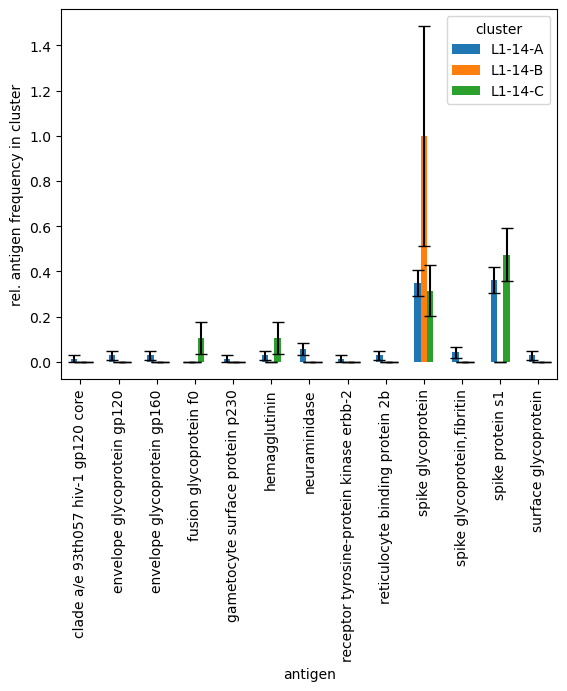

L1 - Länge 15:Chi² = 0.00, p = 1.0000, dof = 0


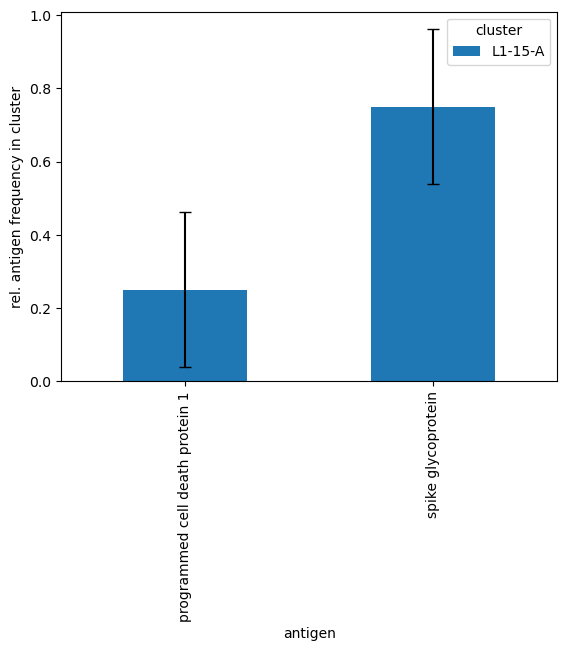

L1 - Länge 16:Chi² = 0.00, p = 1.0000, dof = 0


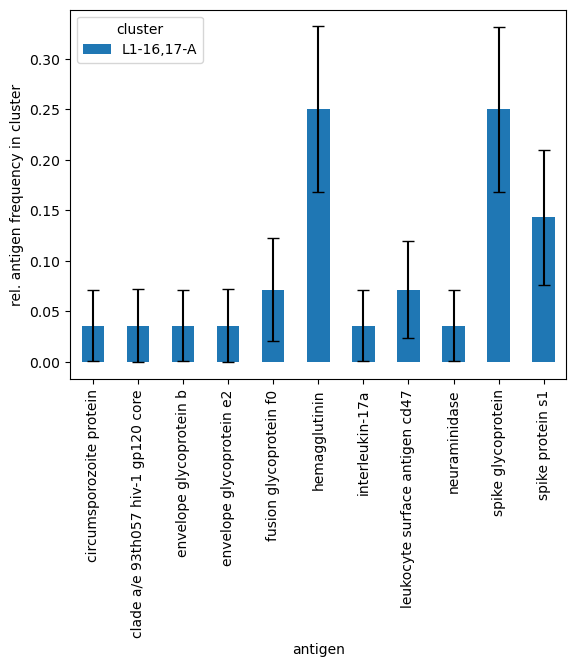

L1 - Länge 17:Chi² = 0.00, p = 1.0000, dof = 0


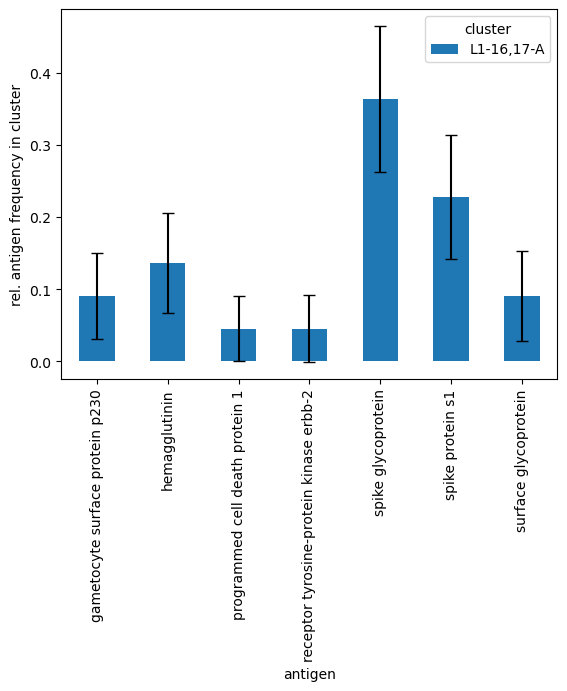

L2 - Länge 7:Chi² = 0.00, p = 1.0000, dof = 0


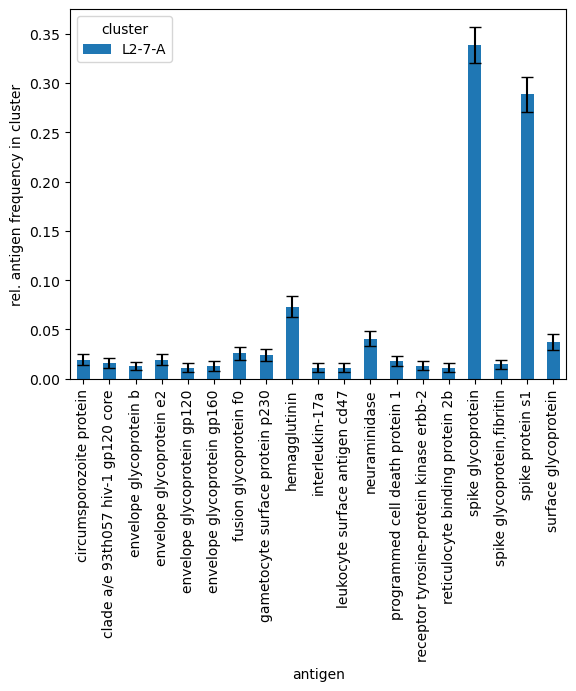

L3 - Länge 5:Chi² = 0.00, p = 1.0000, dof = 0


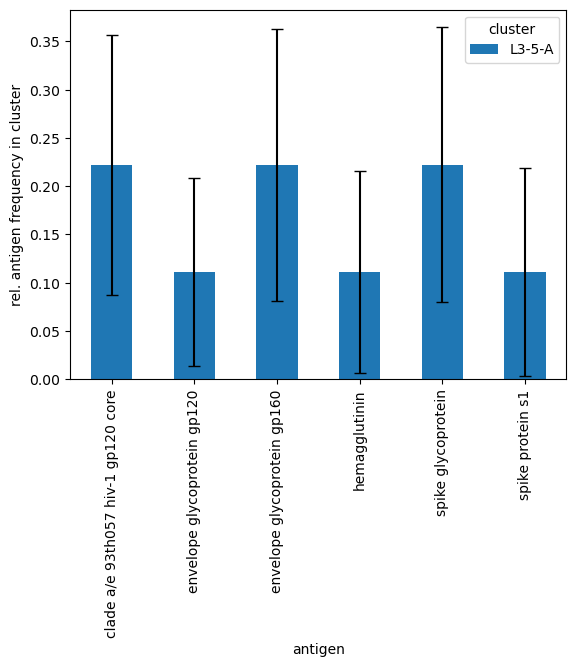

L3 - Länge 8:Chi² = 0.00, p = 1.0000, dof = 0


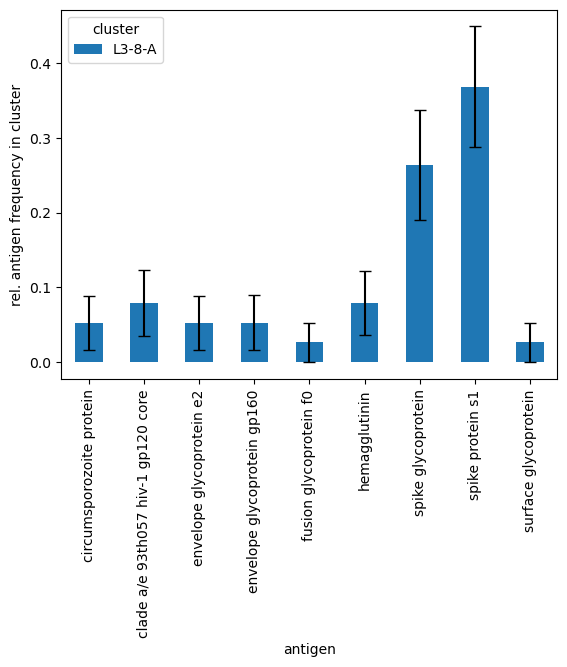

L3 - Länge 9:Chi² = 23.29, p = 0.1920, dof = 18


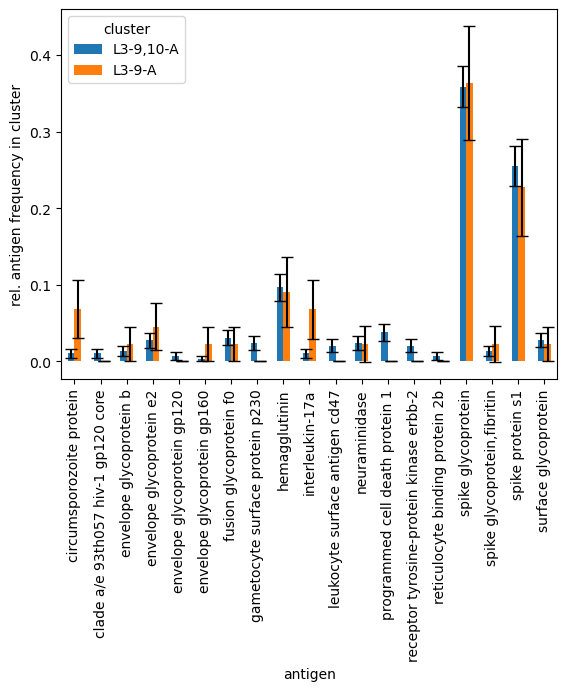

L3 - Länge 10:Chi² = 134.58, p < 0.0010, dof = 45


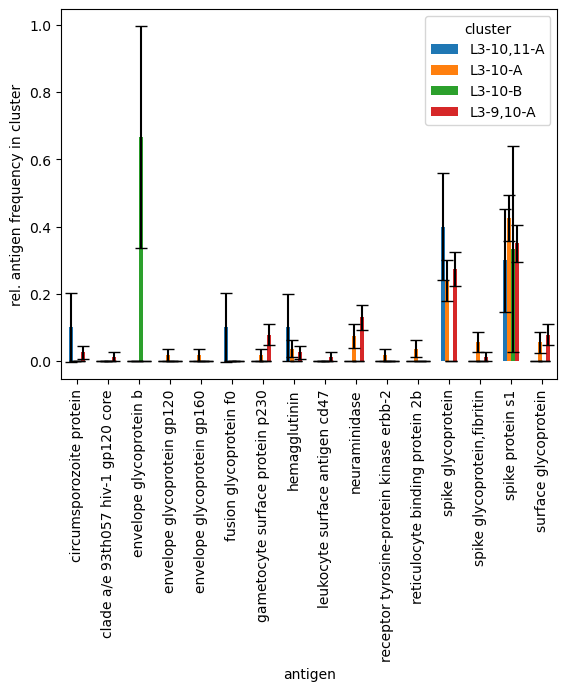

L3 - Länge 11:Chi² = 25.84, p = 0.0510, dof = 14


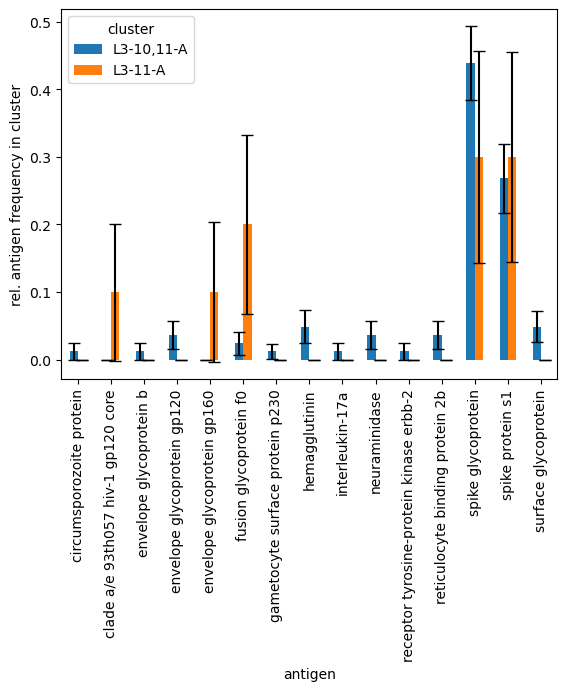

In [ ]:
# Chi2-Permutationstest (Unabhängigkeitstest) für Vergleich der Cluster untereinander innerhalb derselben Längengruppen derselben CDR-Regionen

for region, cf_region in zip(regions, cf_regions):
    for len_group in regions_dict[region]:
        # Für jede Region und innerhalb der Regionen für jede Längengruppe

        df = regions_dict[region][len_group]
        #top_antigens = df["antigen_name"].value_counts().head(15).index.tolist()
        #df_top = df[df["antigen_name"].isin(top_antigens)]

        contingency = pd.crosstab(df[cf_region], df["antigen_name"])
        chi2_stat, p_value, dof, error_df = permutation_test_and_bootstrap(contingency, n_permutations = 1000, bootstrap_iterations = 1000)

        if p_value == 0:
            print(f"{region} - Länge {len_group}:Chi² = {chi2_stat:.2f}, p < {1/1000:.4f}, dof = {dof}")
        else:
            print(f"{region} - Länge {len_group}:Chi² = {chi2_stat:.2f}, p = {p_value:.4f}, dof = {dof}")

        # Plot
        contingency_norm = normalize_contingency(contingency)
        contingency_norm.T.plot(
            kind='bar',
            stacked=False,
            yerr=error_df.T,
            capsize=4
        )

        plt.ylabel("rel. antigen frequency in cluster")
        plt.xlabel("antigen")
        plt.legend(title="cluster")
        plt.savefig(f"data/chi2_visuals/chi2_permutation/chi2_{region}_{len_group}.png", dpi=150, bbox_inches='tight')
        plt.show()



H1: Chi² = 162.28, p = 0.1220, dof = 126


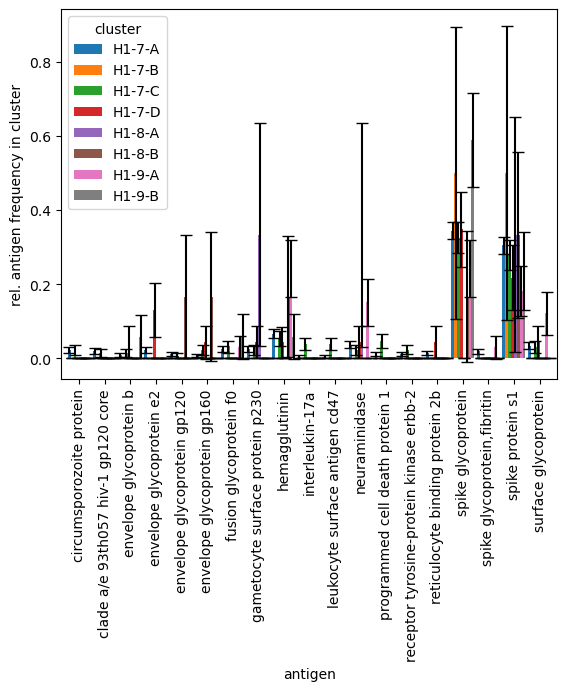

H2: Chi² = 279.71, p < 0.0010, dof = 108


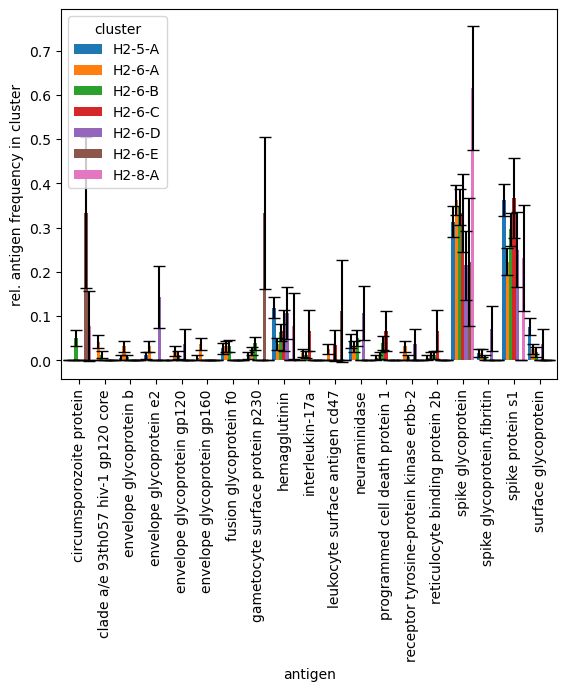

L1: Chi² = 278.49, p = 0.0340, dof = 198


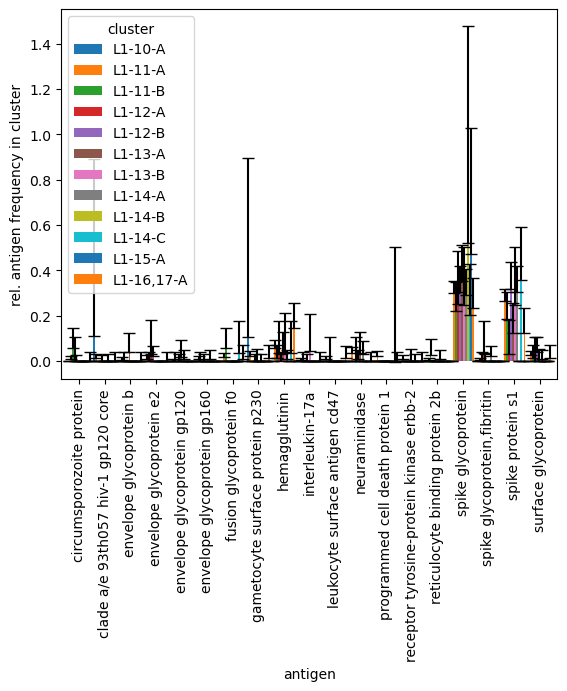

L2: Chi² = 0.00, p = 1.0000, dof = 0


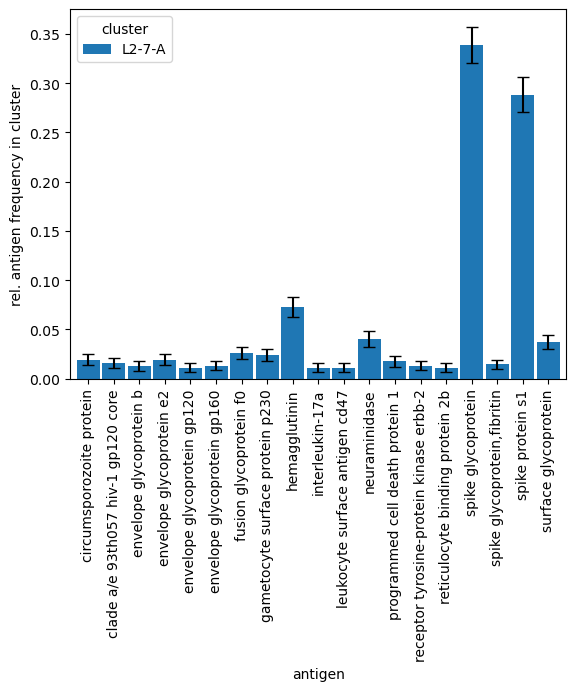

L3: Chi² = 304.75, p < 0.0010, dof = 126


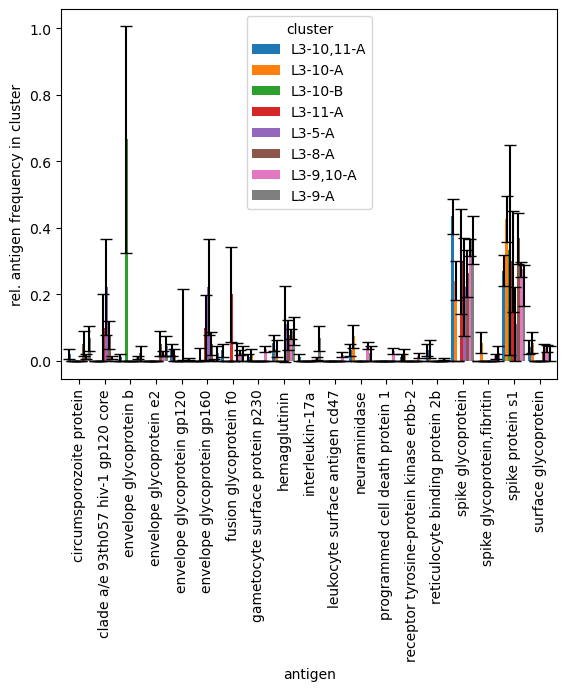

In [ ]:
# Chi2-Permutationstest (Unabhängigkeitstest) für Vergleich der Cluster innerhalb derselben CDR-Regionen über alle Längengruppen
# Achtung bei Permutationen: Wenn in n_permutations keine Permutation extremer war als die beobachtete Verteilung ist p=0, d.h. aber maximal p < 1/n_permutations, weil weitere Permutationen evtl. extremere Ergebnisse liefern

for region, cf_region in zip(regions,cf_regions):

    contingency = pd.crosstab(ab_ag_scalop[cf_region], ab_ag_scalop["antigen_name"]) # Cluster (Zeilen): axis=0, Antigen (Spalten): axis=1

    chi2_stat, p_value, dof, error_df = permutation_test_and_bootstrap(contingency, n_permutations = 1000, bootstrap_iterations = 1000)

    if p_value == 0:
        print(f"{region}: Chi² = {chi2_stat:.2f}, p < {1/1000:.4f}, dof = {dof}")
    else:
        print(f"{region}: Chi² = {chi2_stat:.2f}, p = {p_value:.4f}, dof = {dof}")

    # Plot
    contingency_norm = normalize_contingency(contingency)
    contingency_norm.T.plot(
        kind='bar',
        stacked=False,
        yerr=error_df.T,
        capsize=4,
        width=0.9
    )
    plt.ylabel("rel. antigen frequency in cluster")
    plt.xlabel("antigen")
    plt.legend(title="cluster")
    plt.savefig(f"data/chi2_visuals/chi2_CDR{region}.png", dpi=150, bbox_inches='tight')
    plt.show()

L3: Chi² = 278.49, p = 0.0300, dof = 198


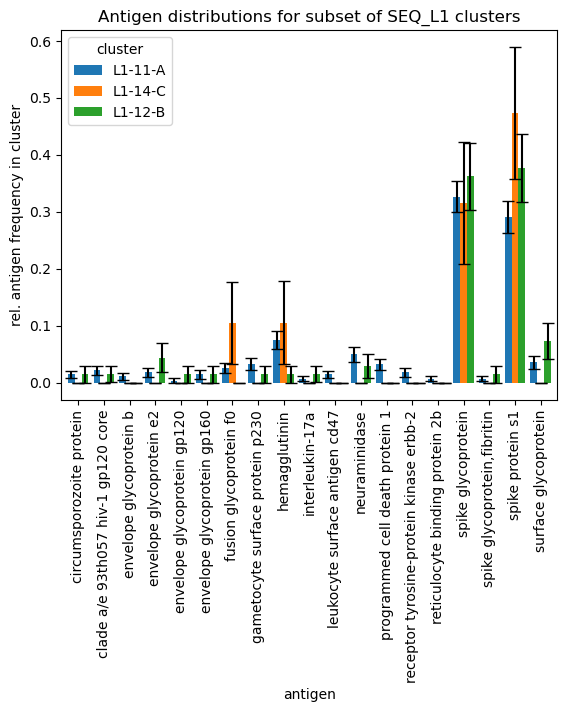

In [8]:
# Chi2 und Visualisierung für CDR-L1, aber nur Auswahl der Cluster
# Achtung bei Permutationen: Wenn in n_permutations keine Permutation extremer war als die beobachtete Verteilung ist p=0, d.h. aber maximal p < 1/n_permutations, weil weitere Permutationen evtl. extremere Ergebnisse liefern

contingency = pd.crosstab(ab_ag_scalop["CF_L1"], ab_ag_scalop["antigen_name"]) # Cluster (Zeilen): axis=0, Antigen (Spalten): axis=1
chi2_stat, p_value, dof, error_df = permutation_test_and_bootstrap(contingency, n_permutations = 1000, bootstrap_iterations = 1000)

if p_value == 0:
    print(f"{region}: Chi² = {chi2_stat:.2f}, p < {1/1000:.4f}, dof = {dof}")
else:
    print(f"{region}: Chi² = {chi2_stat:.2f}, p = {p_value:.4f}, dof = {dof}")

# Plot
clusters_to_plot = ["L1-11-A", "L1-14-C", "L1-12-B"]
contingency_plot = contingency.loc[clusters_to_plot]
error_plot = error_df.loc[clusters_to_plot]
contingency_norm = normalize_contingency(contingency_plot)
contingency_norm.T.plot(
    kind='bar',
    stacked=False,
    yerr=error_plot.T,
    capsize=4,
    width=0.8
)
plt.title("Antigen distributions for subset of SEQ_L1 clusters")
plt.ylabel("rel. antigen frequency in cluster")
plt.xlabel("antigen")
plt.legend(title="cluster")
plt.savefig("data/chi2_visuals/chi2_CDR-L1_visual.png", dpi=150, bbox_inches='tight')
plt.show()